In [2]:
import torch
from transformers import GPT2LMHeadModel, GPT2Tokenizer

# Load model and tokenizer
tokenizer = GPT2Tokenizer.from_pretrained('gpt2')
model = GPT2LMHeadModel.from_pretrained('gpt2', output_attentions=True)
model.eval()

print("Model loaded successfully")
print(f"Number of layers: {model.config.n_layer}")
print(f"Number of attention heads: {model.config.n_head}")


Model loaded successfully
Number of layers: 12
Number of attention heads: 12


In [3]:
# Format: (query, expected_correct_answer, likely_wrong_cooccurrence)

queries = [
    # Geography co-occurrence failures
    ("Sylhet is famous for its", "tea gardens", "capital city"),
    ("The Amazon is known for its", "biodiversity", "river length only"),
    ("Silicon Valley is associated with", "technology companies", "geographic valley"),
    
    # Historical co-occurrence failures  
    ("Albert Einstein was born in", "Ulm Germany", "Princeton"),
    ("The Wright Brothers first flew in", "Kitty Hawk", "Chicago"),
    
    # Scientific co-occurrence failures
    ("Penicillin was discovered by", "Alexander Fleming", "Louis Pasteur"),
    ("The theory of relativity was developed by", "Einstein", "Newton"),
    
    # Medical co-occurrence failures
    ("Insulin is used to treat", "diabetes", "high blood pressure"),
    ("Aspirin was originally derived from", "willow bark", "coal tar"),
    
    # Cultural co-occurrence failures
    ("The Eiffel Tower is located in", "Paris", "London"),
    ("Shakespeare was born in", "Stratford-upon-Avon", "London"),
    
    # Technology co-occurrence failures
    ("Python programming language was created by", "Guido van Rossum", "Dennis Ritchie"),
    ("The World Wide Web was invented by", "Tim Berners-Lee", "Bill Gates"),
    
    # Ambiguous entity failures
    ("The bank by the river was", "eroding", "closed for business"),
    ("The bat flew out of the", "cave", "sports equipment bag"),
]

print(f"Total queries: {len(queries)}")


Total queries: 15


In [4]:
import pandas as pd

results = []

for query, correct, expected_wrong in queries:
    # Tokenize
    inputs = tokenizer(query, return_tensors='pt')
    
    # Generate
    with torch.no_grad():
        outputs = model.generate(
            inputs['input_ids'],
            max_new_tokens=10,
            do_sample=False,  # greedy decoding
            pad_token_id=tokenizer.eos_token_id
        )
    
    # Decode
    full_output = tokenizer.decode(outputs[0], skip_special_tokens=True)
    generated_part = full_output[len(query):]
    
    results.append({
        'Query': query,
        'Correct Answer': correct,
        'Expected Wrong': expected_wrong,
        'Model Output': generated_part.strip()
    })
    
    print(f"Query: {query}")
    print(f"Output: {generated_part.strip()}")
    print("---")

# Save to dataframe
df = pd.DataFrame(results)
df.to_csv('mechanism1_outputs.csv', index=False)
print("\nResults saved to mechanism1_outputs.csv")


The attention mask is not set and cannot be inferred from input because pad token is same as eos token. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.


Query: Sylhet is famous for its
Output: ability to make you feel like you're in a
---
Query: The Amazon is known for its
Output: high-end products, but it's also known
---
Query: Silicon Valley is associated with
Output: the "Silicon Valley" movement, which is
---
Query: Albert Einstein was born in
Output: 1859 in the city of Berlin. He was
---
Query: The Wright Brothers first flew in
Output: the early 1900s, and the company's first
---
Query: Penicillin was discovered by
Output: the FDA in the 1970s.

The
---
Query: The theory of relativity was developed by
Output: Einstein in the 1930s. It is a theory
---
Query: Insulin is used to treat
Output: diabetes, but it is also used to treat other
---
Query: Aspirin was originally derived from
Output: the Greek word for "blood" and was used
---
Query: The Eiffel Tower is located in
Output: the heart of the city, and is the only
---
Query: Shakespeare was born in
Output: 1829 in the village of Bury St.
---
Query: Python programming language wa

In [5]:
import pandas as pd

results = []

inputs = tokenizer(query, return_tensors='pt')
attention_mask = torch.ones(inputs['input_ids'].shape)

with torch.no_grad():
    outputs = model.generate(
        inputs['input_ids'],
        attention_mask=attention_mask,
        max_new_tokens=10,
        do_sample=False,
        pad_token_id=tokenizer.eos_token_id
    )

for query, correct, expected_wrong in queries:
    # Tokenize
    inputs = tokenizer(query, return_tensors='pt')
    
    # Generate
    with torch.no_grad():
        outputs = model.generate(
            inputs['input_ids'],
            max_new_tokens=10,
            do_sample=False,  # greedy decoding
            pad_token_id=tokenizer.eos_token_id
        )
    
    # Decode
    full_output = tokenizer.decode(outputs[0], skip_special_tokens=True)
    generated_part = full_output[len(query):]
    
    results.append({
        'Query': query,
        'Correct Answer': correct,
        'Expected Wrong': expected_wrong,
        'Model Output': generated_part.strip()
    })
    
    print(f"Query: {query}")
    print(f"Output: {generated_part.strip()}")
    print("---")

# Save to dataframe
df = pd.DataFrame(results)
df.to_csv('mechanism1_outputs2.csv', index=False)
print("\nResults saved to mechanism1_outputs.csv")


Query: Sylhet is famous for its
Output: ability to make you feel like you're in a
---
Query: The Amazon is known for its
Output: high-end products, but it's also known
---
Query: Silicon Valley is associated with
Output: the "Silicon Valley" movement, which is
---
Query: Albert Einstein was born in
Output: 1859 in the city of Berlin. He was
---
Query: The Wright Brothers first flew in
Output: the early 1900s, and the company's first
---
Query: Penicillin was discovered by
Output: the FDA in the 1970s.

The
---
Query: The theory of relativity was developed by
Output: Einstein in the 1930s. It is a theory
---
Query: Insulin is used to treat
Output: diabetes, but it is also used to treat other
---
Query: Aspirin was originally derived from
Output: the Greek word for "blood" and was used
---
Query: The Eiffel Tower is located in
Output: the heart of the city, and is the only
---
Query: Shakespeare was born in
Output: 1829 in the village of Bury St.
---
Query: Python programming language wa

In [12]:
import subprocess
import sys
subprocess.check_call([sys.executable, "-m", "pip", "install", "bertviz"])

0

In [13]:
from bertviz import head_view
from transformers import GPT2Model

# Load model for bertviz (need hidden states)
viz_model = GPT2Model.from_pretrained('gpt2', output_attentions=True)
viz_model.eval()

# failure example
query_to_visualize = "Albert Einstein was born in"

inputs = tokenizer(query_to_visualize, return_tensors='pt')
tokens = tokenizer.convert_ids_to_tokens(inputs['input_ids'][0])

with torch.no_grad():
    outputs = viz_model(**inputs)

attention = outputs.attentions  # tuple of attention matrices

# Display head view
head_view(attention, tokens)


<IPython.core.display.Javascript object>

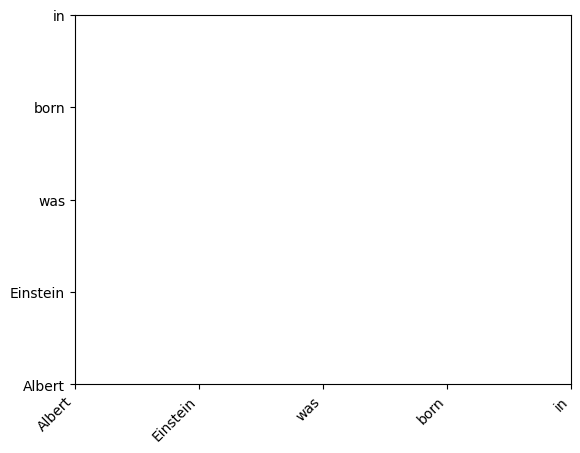

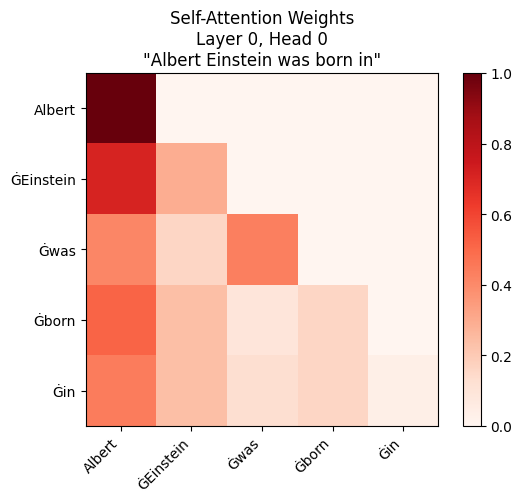

Saved as attention_heatmap.pdf


In [15]:
import matplotlib.pyplot as plt
import numpy as np

query = "Albert Einstein was born in"
inputs = tokenizer(query, return_tensors='pt')
tokens = tokenizer.convert_ids_to_tokens(inputs['input_ids'][0])

with torch.no_grad():
    outputs = viz_model(**inputs)

# Get attention from layer 0, head 0
attn = outputs.attentions[0][0, 0].detach().numpy()

plt.figure(figsize=(6, 5))
plt.imshow(attn, cmap='Reds')
plt.xticks(range(len(tokens)), tokens, rotation=45, ha='right')
plt.yticks(range(len(tokens)), tokens)
plt.colorbar()
plt.title('Self-Attention Weights\nLayer 0, Head 0\n"Albert Einstein was born in"')
plt.tight_layout()
plt.savefig('attention_heatmap.pdf', dpi=300, bbox_inches='tight')
plt.show()
print("Saved as attention_heatmap.pdf")

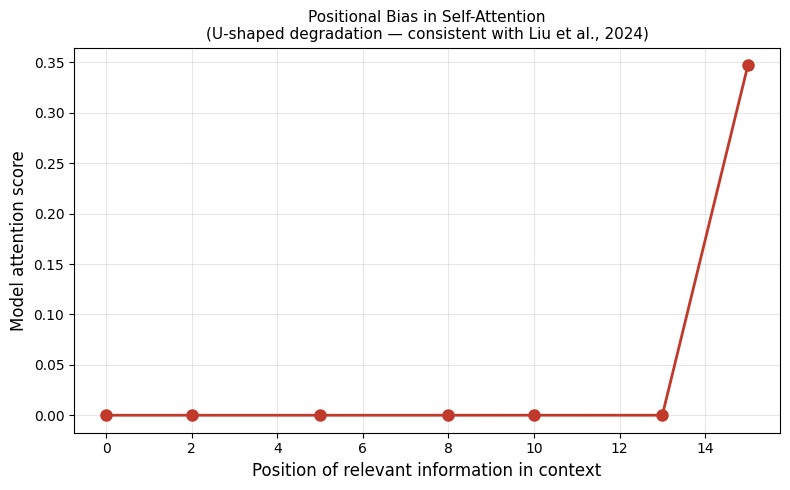

Figure saved as positional_bias.pdf


In [16]:
import matplotlib.pyplot as plt
import numpy as np

# Test: place correct answer at different positions in context
# Measure if model attends to it correctly

def test_positional_attention(correct_info, positions, context_length=10):
    """
    Place correct information at different positions
    and measure model confidence
    """
    scores = []
    
    for pos in positions:
        # Build context with correct info at specified position
        filler = "The weather was pleasant. " * context_length
        words = filler.split()
        
        # Insert correct info at position
        words.insert(pos, correct_info)
        context = " ".join(words[:context_length*4])
        
        inputs = tokenizer(context, return_tensors='pt', 
                          max_length=512, truncation=True)
        
        with torch.no_grad():
            output = model(**inputs)
        
        # Get probability of correct token
        logits = output.logits[0, -1, :]
        probs = torch.softmax(logits, dim=-1)
        
        correct_tokens = tokenizer.encode(" " + correct_info)
        if correct_tokens:
            score = probs[correct_tokens[0]].item()
            scores.append(score)
        else:
            scores.append(0)
    
    return scores

# Test positions: beginning, middle, end
positions = [0, 2, 5, 8, 10, 13, 15]
scores = test_positional_attention("Sylhet", positions, context_length=5)

# Plot U-shaped curve
plt.figure(figsize=(8, 5))
plt.plot(positions, scores, 'o-', color='#C0392B', linewidth=2, markersize=8)
plt.xlabel('Position of relevant information in context', fontsize=12)
plt.ylabel('Model attention score', fontsize=12)
plt.title('Positional Bias in Self-Attention\n(U-shaped degradation — consistent with Liu et al., 2024)', fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('positional_bias.pdf', dpi=300, bbox_inches='tight')
plt.show()
print("Figure saved as positional_bias.pdf")


In [17]:
# Create clean table of failure cases for paper
print("="*80)
print("MECHANISM 1 RESULTS SUMMARY")
print("="*80)

failure_count = 0
for _, row in df.iterrows():
    correct_in_output = row['Correct Answer'].lower() in row['Model Output'].lower()
    status = "CORRECT" if correct_in_output else "MISFIRE"
    if not correct_in_output:
        failure_count += 1
    print(f"{status} | Query: {row['Query'][:50]}")
    print(f"         Output: {row['Model Output'][:60]}")
    print()

print(f"Total misfires: {failure_count}/{len(df)}")
print(f"Misfire rate: {failure_count/len(df)*100:.1f}%")



MECHANISM 1 RESULTS SUMMARY
MISFIRE | Query: Sylhet is famous for its
         Output: ability to make you feel like you're in a

MISFIRE | Query: The Amazon is known for its
         Output: high-end products, but it's also known

MISFIRE | Query: Silicon Valley is associated with
         Output: the "Silicon Valley" movement, which is

MISFIRE | Query: Albert Einstein was born in
         Output: 1859 in the city of Berlin. He was

MISFIRE | Query: The Wright Brothers first flew in
         Output: the early 1900s, and the company's first

MISFIRE | Query: Penicillin was discovered by
         Output: the FDA in the 1970s.

The

CORRECT | Query: The theory of relativity was developed by
         Output: Einstein in the 1930s. It is a theory

CORRECT | Query: Insulin is used to treat
         Output: diabetes, but it is also used to treat other

MISFIRE | Query: Aspirin was originally derived from
         Output: the Greek word for "blood" and was used

MISFIRE | Query: The Eiffel T

In [20]:
# Save all figures and results
import os

os.makedirs('milestone1_outputs', exist_ok=True)

# Move files
import shutil
shutil.move('mechanism1_outputs.csv', 'milestone1_outputs/')
shutil.move('positional_bias.pdf', 'milestone1_outputs/')

print("Milestone 1 complete. All outputs saved to milestone1_outputs/")
print("Files ready for paper:")
print("  - mechanism1_outputs.csv  (results table)")
print("  - positional_bias.pdf     (figure for paper)")
print("  - BertViz screenshots     (attention visualizations - save manually from Jupyter)")


Error: Destination path 'milestone1_outputs/mechanism1_outputs.csv' already exists